In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\burra\OneDrive\Documents\sales_data.csv")
df

,Order_ID,Date,Product,Category,Quantity,Price,Profit
0,101,01-01-2025,Laptop,Electronics,3,40000,8000
1,102,12-01-2025,Mobile,Electronics,2,20000,4000
2,103,20-01-2025,Chair,Furniture,1,4000,1500
3,104,29-01-2025,Table,Furniture,3,6000,2000
4,105,15-02-2025,Tv,Electronics,2,45000,12000


In [3]:
df.isnull().sum()

Order_ID    0
Date        0
Product     0
Category    0
Quantity    0
Price       0
Profit      0
dtype: int64

In [4]:
df = df.drop_duplicates()
df

,Order_ID,Date,Product,Category,Quantity,Price,Profit
0,101,01-01-2025,Laptop,Electronics,3,40000,8000
1,102,12-01-2025,Mobile,Electronics,2,20000,4000
2,103,20-01-2025,Chair,Furniture,1,4000,1500
3,104,29-01-2025,Table,Furniture,3,6000,2000
4,105,15-02-2025,Tv,Electronics,2,45000,12000


In [5]:
df["Date"] = pd.to_datetime(df["Date"],
dayfirst=True)
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df

,Order_ID,Date,Product,Category,Quantity,Price,Profit,Month,Year
0,101,2025-01-01,Laptop,Electronics,3,40000,8000,1,2025
1,102,2025-01-12,Mobile,Electronics,2,20000,4000,1,2025
2,103,2025-01-20,Chair,Furniture,1,4000,1500,1,2025
3,104,2025-01-29,Table,Furniture,3,6000,2000,1,2025
4,105,2025-02-15,Tv,Electronics,2,45000,12000,2,2025


In [6]:
df["Sales"]  = df["Quantity"] + df["Price"]
df

,Order_ID,Date,Product,Category,Quantity,Price,Profit,Month,Year,Sales
0,101,2025-01-01,Laptop,Electronics,3,40000,8000,1,2025,40003
1,102,2025-01-12,Mobile,Electronics,2,20000,4000,1,2025,20002
2,103,2025-01-20,Chair,Furniture,1,4000,1500,1,2025,4001
3,104,2025-01-29,Table,Furniture,3,6000,2000,1,2025,6003
4,105,2025-02-15,Tv,Electronics,2,45000,12000,2,2025,45002


In [7]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())

Total Sales: 115011
Total Profit: 27500


In [27]:
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Electronics    105007
Furniture       10004
Name: Sales, dtype: int64


In [28]:
df.sort_values(by="Sales", ascending=False)

,Order_ID,Date,Product,Category,Quantity,Price,Profit,Month,Year,Sales
4,105,2025-02-15,Tv,Electronics,2,45000,12000,2,2025,45002
0,101,2025-01-01,Laptop,Electronics,3,40000,8000,1,2025,40003
1,102,2025-01-12,Mobile,Electronics,2,20000,4000,1,2025,20002
3,104,2025-01-29,Table,Furniture,3,6000,2000,1,2025,6003
2,103,2025-01-20,Chair,Furniture,1,4000,1500,1,2025,4001


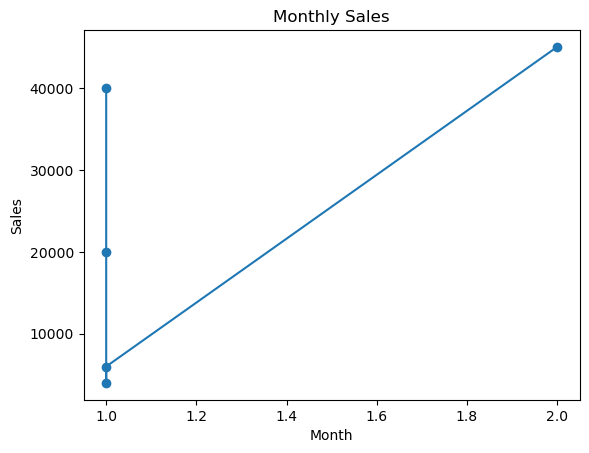

In [30]:
plt.plot(df["Month"], df["Sales"], marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

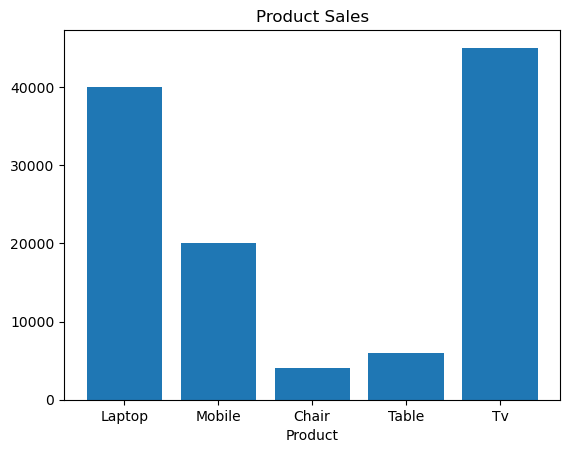

In [32]:
plt.bar(df["Product"], df["Sales"])
plt.title("Product Sales")
plt.xlabel("Product")
plt.show()

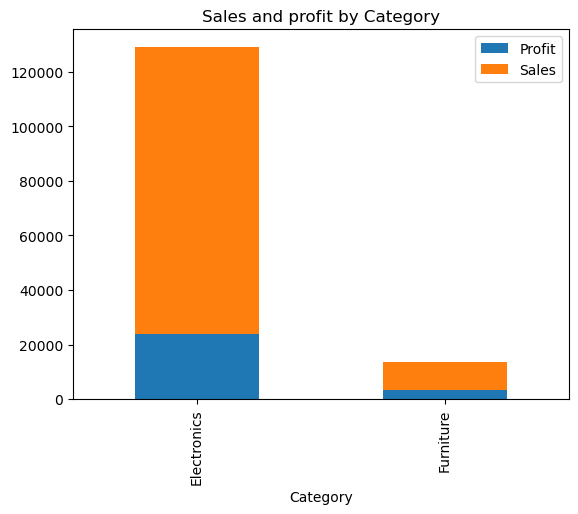

In [33]:
pivot = df.pivot_table(index="Category",values=["Sales","Profit"], aggfunc="sum")
pivot.plot(kind="bar", stacked=True)
plt.title("Sales and profit by Category")
plt.show()

In [34]:
df.to_csv("sales_reports.csv", index=False)